# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT /'e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [3]:
# TODO 1: Data Profiling
df.info()
print()
print(df.isnull().sum())
print()
print('Exact duplicates:', df.duplicated().sum())
print('Duplicated Transaction_ID:', df['Transaction_ID'].duplicated().sum())
print()
for c in ['Gender', 'Payment_Method', 'Order_Status', 'Province', 'Is_Promotion']:
    print(c, '->', df[c].nunique(), list(df[c].dropna().unique()))
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

,count,mean,std,min,25%,50%,75%,max
Quantity,630.0,3.660317,4.184784,-3.00,2.000,3.000,5.0000,99.00
Unit_Price,630.0,227.080365,126.984729,37.36,137.095,198.935,298.6150,779.43
Discount_Rate,630.0,0.061746,0.066935,0.00,0.000,0.050,0.1000,0.20
Transaction_Amount,630.0,6092.293000,66925.290163,-500.00,316.190,579.600,1037.8925,999999.00


### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| ค่าว่าง | Customer_Email, Province | Completeness | 50 แถว และ 12 แถว |
| รูปแบบไม่เหมือนกัน (male/M/FEMALE, PP/PromptPay) | Gender, Payment_Method | Consistency | Gender 10 ค่า, Payment_Method 14 ค่า |
| วันที่หลายรูปแบบ และมีค่าที่ไม่ใช่วันที่ | Order_Date | Consistency / Validity | มีทั้ง YYYY-MM-DD, DD/MM/YYYY, MM/DD/YYYY, `not_a_date`, `31/02/2026` |
| แถวซ้ำทั้งแถว | ทุกคอลัมน์ | Uniqueness | 18 แถว |
| Quantity นอกช่วง 1–20 (0, -3, 99) | Quantity | Validity | 3 แถว |


## 2) Completeness: จัดการ Missing Values

In [5]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print('Customer_Email missing:', df['Customer_Email'].isnull().sum())
print('Province missing:', df['Province'].isnull().sum())

# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
df['Customer_Email_Was_Missing'] = df['Customer_Email'].isnull().astype(int)
df['Customer_Email'] = df['Customer_Email'].fillna('unknown_' + df['Customer_ID'] + '@unknown.local')

# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_Was_Missing'] = df['Province'].isnull().astype(int)
df['Province'] = df['Province'].fillna('Unknown')

print('after ->', df['Customer_Email'].isnull().sum(), df['Province'].isnull().sum())
print('rows:', len(df))
df[df['Customer_Email_Was_Missing'] == 1][['Customer_ID', 'Customer_Email', 'Province']].head()

Customer_Email missing: 0
Province missing: 0
after -> 0 0
rows: 630


,Customer_ID,Customer_Email,Province


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

**ตอบ:** `Customer_Email` เป็นแค่คุณลักษณะของมิติลูกค้า แต่แถวที่หายไปเป็นธุรกรรมจริง (Fact) ที่มียอดเงินจริง ถ้า `dropna()` จะหายไป 50 แถว ทำให้ยอดขายรวมต่ำกว่าความเป็นจริง และยอดขายรายจังหวัด/รายหมวดสินค้าก็จะเพี้ยนตามไปด้วย

ส่วน mean imputation ใช้ไม่ได้เพราะอีเมลเป็นข้อมูลประเภท categorical / identifier ซึ่งหาค่าเฉลี่ยไม่ได้ จึงใช้วิธี unknown member แทน คือเติม `unknown_<Customer_ID>@unknown.local` พร้อม flag `Customer_Email_Was_Missing` เพื่อย้อนตรวจสอบภายหลังได้

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [6]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {'m': 'M', 'male': 'M', 'f': 'F', 'female': 'F'}
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower().map(gender_map).fillna('Unknown')
print(df['Gender'].value_counts())

# TODO 3.2: Standardize Payment_Method
pay_map = {
    'cc': 'Credit Card', 'card': 'Credit Card', 'credit card': 'Credit Card',
    'pp': 'PromptPay', 'promptpay': 'PromptPay', 'prompt pay': 'PromptPay',
    'cod': 'Cash on Delivery', 'cash': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery',
    'transfer': 'Bank Transfer', 'bank transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer',
}
df['Payment_Method'] = df['Payment_Method'].astype(str).str.strip().str.lower().map(pay_map).fillna('Unknown')
print(df['Payment_Method'].value_counts())

# TODO 3.3: แปลง Order_Date ให้เป็น YYYY-MM-DD
FORMATS = [('%Y-%m-%d', 'YYYY-MM-DD'), ('%Y/%m/%d', 'YYYY/MM/DD'),
           ('%d/%m/%Y', 'DD/MM/YYYY'), ('%m/%d/%Y', 'MM/DD/YYYY'),
           ('%d-%m-%Y', 'DD-MM-YYYY')]

def parse_date(raw, load):
    load = pd.to_datetime(load, errors='coerce')
    cands = []
    for fmt, name in FORMATS:
        d = pd.to_datetime(str(raw), format=fmt, errors='coerce')
        if pd.notna(d):
            cands.append((d, name))
    for d, name in cands:
        if pd.notna(load) and d.date() == load.date():
            return d, name, 0
    if cands:
        return cands[0][0], cands[0][1], 0
    if pd.notna(load):
        return load.normalize(), 'Fallback_LoadTimestamp', 1
    return pd.NaT, 'Unparsed', 1

res = [parse_date(r, l) for r, l in zip(df['Order_Date'], df['Load_Timestamp'])]
df['Order_Date'] = pd.to_datetime([x[0] for x in res]).strftime('%Y-%m-%d')
df['Order_Date_Parse_Method'] = [x[1] for x in res]
df['Order_Date_Was_Imputed'] = [x[2] for x in res]

print(df['Order_Date_Parse_Method'].value_counts())
print('Imputed:', df['Order_Date_Was_Imputed'].sum())
df[df['Order_Date_Was_Imputed'] == 1][['Transaction_ID', 'Order_Date', 'Load_Timestamp', 'Order_Date_Parse_Method']]

Gender
M    344
F    286
Name: count, dtype: int64
Payment_Method
PromptPay           173
Bank Transfer       163
Credit Card         159
Cash on Delivery    135
Name: count, dtype: int64
Order_Date_Parse_Method
YYYY-MM-DD                349
MM/DD/YYYY                 85
DD/MM/YYYY                 82
YYYY/MM/DD                 60
DD-MM-YYYY                 47
Fallback_LoadTimestamp      7
Name: count, dtype: int64
Imputed: 7


,Transaction_ID,Order_Date,Load_Timestamp,Order_Date_Parse_Method
10,T000141,2026-06-19,2026-06-19 06:00:00,Fallback_LoadTimestamp
34,T900007,2026-04-03,2026-04-03 17:00:00,Fallback_LoadTimestamp
223,T000439,2026-05-21,2026-05-21 17:00:00,Fallback_LoadTimestamp
265,T000124,2026-06-08,2026-06-08 03:00:00,Fallback_LoadTimestamp
365,T000409,2026-05-22,2026-05-22 05:00:00,Fallback_LoadTimestamp
517,T000545,2026-01-24,2026-01-24 10:00:00,Fallback_LoadTimestamp
590,T000474,2026-04-03,2026-04-03 17:00:00,Fallback_LoadTimestamp


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

**ตอบ:** เช่น `T000548` มี Order_Date = `08/01/2026` ซึ่งอ่านได้ทั้ง 8 ม.ค. 2026 (DD/MM) และ 1 ส.ค. 2026 (MM/DD)

หลักฐานที่ใช้คือ `Load_Timestamp` = `2026-01-08 02:00:00` เนื่องจากข้อมูลต้องถูกโหลดหลังจากสั่งซื้อเสมอ การตีความแบบ DD/MM (8 ม.ค.) จึงสอดคล้องกับเวลาโหลด ส่วน MM/DD (1 ส.ค.) จะทำให้โหลดก่อนวันสั่งซื้อเกือบ 7 เดือน ซึ่งเป็นไปไม่ได้ จึงเลือก `2026-01-08`

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [7]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
n_dup = df.duplicated().sum()
print('Exact duplicates:', n_dup)
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print('Shape after:', df.shape)

# TODO 4.2 (Bonus): ตรวจหา Near Duplicate
near = df.groupby('Customer_Email')['Customer_Name'].nunique()
near = near[near > 1]
print(near)
df[df['Customer_Email'].isin(near.index)][['Customer_ID', 'Customer_Name', 'Customer_Email']].drop_duplicates()

Exact duplicates: 18
Shape after: (612, 20)
Customer_Email
ploy.saelim47@example.com    2
Name: Customer_Name, dtype: int64


,Customer_ID,Customer_Name,Customer_Email
95,C0047,Ploy Saelim,ploy.saelim47@example.com
96,C0047,Ploy Saelim,ploy.saelim47@example.com


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [8]:
# TODO 5.1: แปลงเป็นตัวเลข
for c in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Was_Invalid'] = (~df['Quantity'].between(1, 20)).astype(int)
print('Quantity invalid:', df['Quantity_Was_Invalid'].sum())
print(df[df['Quantity_Was_Invalid'] == 1][['Transaction_ID', 'Quantity']])

# TODO 5.3: Expected_Amount และ Accuracy_Flag
df['Expected_Amount'] = (df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])).round(2)
df['Accuracy_Flag'] = ((df['Transaction_Amount'] - df['Expected_Amount']).abs() > 1).astype(int)
print('Accuracy_Flag:', df['Accuracy_Flag'].sum())
print(df.groupby('Is_Promotion')['Accuracy_Flag'].sum())

# TODO 5.4: Standardize Order_Status และตรวจ Validity
status_map = {'completed': 'Completed', 'done': 'Completed', 'processing': 'Processing',
              'cancelled': 'Cancelled', 'cancel': 'Cancelled', 'returned': 'Returned'}
df['Order_Status'] = df['Order_Status'].astype(str).str.strip().str.lower().map(status_map).fillna('Unknown')
df['Status_Was_Invalid'] = (df['Order_Status'] == 'Unknown').astype(int)
print(df['Order_Status'].value_counts())
print('Status invalid:', df['Status_Was_Invalid'].sum())

Quantity invalid: 3
    Transaction_ID  Quantity
120        T000574         0
200        T000428        -3
369        T000355        99
Accuracy_Flag: 50
Is_Promotion
N    43
Y     7
Name: Accuracy_Flag, dtype: int64
Order_Status
Completed     164
Processing    159
Cancelled     151
Returned      133
Unknown         5
Name: count, dtype: int64
Status invalid: 5


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

**ตอบ:** ไม่ควรแก้ทุกแถว จาก 50 แถวที่ติด `Accuracy_Flag` มี 7 แถวที่ `Is_Promotion = 'Y'` ซึ่งเป็นรายการโปรโมชันที่มีส่วนลดพิเศษนอกเหนือจาก `Discount_Rate` เช่น คูปอง flash sale หรือโปรขั้นต่ำ ยอดที่ต่างจึงเป็นยอดจริงที่เก็บเงินได้จริง ถ้าเขียนทับด้วย Expected_Amount จะทำให้ยอดใน DW สูงกว่าที่เก็บจริง

ดังนั้นจึงเก็บเป็น `Accuracy_Flag` ไว้เฉย ๆ ไม่เขียนทับอัตโนมัติ แล้วส่งให้ฝั่งธุรกิจตรวจสอบต่อ

## 6) Outliers: IQR และ Capping/Clipping

Q1 = 310.8 | Q3 = 1023.48 | IQR = 712.68
Lower = -758.22 | Upper = 2092.5
Outliers (non-promotion): 19
count      612.000000
mean       800.324216
std       1094.740035
min       -500.000000
25%        313.312500
50%        571.125000
75%       1035.997500
max      19610.760000
Name: Transaction_Amount, dtype: float64


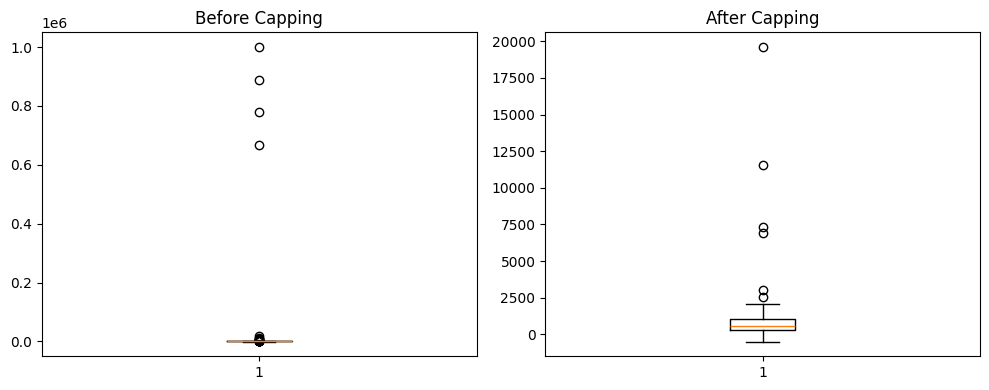

In [9]:
# TODO 6.1: คำนวณ Q1, Q3, IQR จากรายการที่ Is_Promotion != 'Y'
not_promo = df['Is_Promotion'] != 'Y'
s = df.loc[not_promo, 'Transaction_Amount']
Q1 = s.quantile(0.25)
Q3 = s.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print('Q1 =', Q1, '| Q3 =', Q3, '| IQR =', round(IQR, 2))
print('Lower =', round(lower, 2), '| Upper =', round(upper, 2))

# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
df['Outlier_Flag_Before_Capping'] = (
    not_promo & ((df['Transaction_Amount'] < lower) | (df['Transaction_Amount'] > upper))
).astype(int)
print('Outliers (non-promotion):', df['Outlier_Flag_Before_Capping'].sum())

# TODO 6.3: ใช้ .clip() เฉพาะรายการที่ไม่ใช่โปรโมชัน
df['Transaction_Amount_Before_Capping'] = df['Transaction_Amount']
df.loc[not_promo, 'Transaction_Amount'] = df.loc[not_promo, 'Transaction_Amount'].clip(lower, upper)
print(df['Transaction_Amount'].describe())

# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(df['Transaction_Amount_Before_Capping'].dropna())
ax[0].set_title('Before Capping')
ax[1].boxplot(df['Transaction_Amount'].dropna())
ax[1].set_title('After Capping')
plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

**ตอบ:** IQR บอกแค่ว่าค่านั้นห่างจากกลุ่มก้อน ไม่ได้บอกว่าข้อมูลผิด ใน dataset นี้มีทั้งสองแบบ

- **ผิดจริง:** `T000386` ยอด 999,999 บาท จาก Quantity 6 × Unit_Price 91.88 → เป็น data entry error หรือ sentinel value ควร cap
- **ไม่ผิด:** รายการที่ `Is_Promotion = 'Y'` มียอดสูง/ต่ำกว่าปกติเพราะซื้อจำนวนมากช่วง campaign หรือได้ส่วนลดพิเศษ เป็นธุรกรรมจริงที่มีคุณค่าทางธุรกิจ (ใช้วิเคราะห์ประสิทธิภาพแคมเปญได้) จึงต้องกันออกจากการคำนวณ IQR และไม่ cap

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [10]:
# TODO 7: คำนวณ Load_Delay_Hours
order_dt = pd.to_datetime(df['Order_Date'])
load_dt = pd.to_datetime(df['Load_Timestamp'], errors='coerce')
df['Load_Delay_Hours'] = (load_dt - order_dt).dt.total_seconds() / 3600
df['Is_Late_Load'] = (df['Load_Delay_Hours'] > 24).astype(int)

print(df['Load_Delay_Hours'].describe())
print('Late loads:', df['Is_Late_Load'].sum(),
      '(', round(df['Is_Late_Load'].mean() * 100, 2), '% )')

count    612.000000
mean      14.346405
std       19.307341
min        1.000000
25%        5.000000
50%       10.000000
75%       16.000000
max      118.000000
Name: Load_Delay_Hours, dtype: float64
Late loads: 38 ( 6.21 % )


## 8) Data Quality Report และ Export

In [11]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning
raw_num = df_raw.copy()
for c in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    raw_num[c] = pd.to_numeric(raw_num[c], errors='coerce')
raw_expected = raw_num['Quantity'] * raw_num['Unit_Price'] * (1 - raw_num['Discount_Rate'])
valid_status = ['Completed', 'Processing', 'Cancelled', 'Returned']

report = pd.DataFrame([
    ['Total rows', len(df_raw), len(df)],
    ['Missing Customer_Email', df_raw['Customer_Email'].isnull().sum(), df['Customer_Email'].isnull().sum()],
    ['Missing Province', df_raw['Province'].isnull().sum(), df['Province'].isnull().sum()],
    ['Exact duplicates', df_raw.duplicated().sum(), df.duplicated().sum()],
    ['Distinct Gender values', df_raw['Gender'].nunique(), df['Gender'].nunique()],
    ['Distinct Payment_Method values', df_raw['Payment_Method'].nunique(), df['Payment_Method'].nunique()],
    ['Invalid / non-standard Order_Date',
     (~df_raw['Order_Date'].str.match(r'^\d{4}-\d{2}-\d{2}$')).sum(),
     (~df['Order_Date'].str.match(r'^\d{4}-\d{2}-\d{2}$')).sum()],
    ['Invalid Quantity (not 1-20)',
     (~raw_num['Quantity'].between(1, 20)).sum(), df['Quantity_Was_Invalid'].sum()],
    ['Mismatched Transaction_Amount',
     ((raw_num['Transaction_Amount'] - raw_expected).abs() > 1).sum(), df['Accuracy_Flag'].sum()],
    ['Invalid Order_Status',
     (~df_raw['Order_Status'].isin(valid_status)).sum(), df['Status_Was_Invalid'].sum()],
    ['Outliers capped (non-promotion)', df['Outlier_Flag_Before_Capping'].sum(), 0],
    ['Max Transaction_Amount', raw_num['Transaction_Amount'].max(), df['Transaction_Amount'].max()],
    ['Late loads (> 24 hrs)', df['Is_Late_Load'].sum(), df['Is_Late_Load'].sum()],
], columns=['Metric', 'Before', 'After'])
report

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
print('Saved to', OUTPUT_DIR)
report

Saved to /content/outputs/student_submission


,Metric,Before,After
0,Total rows,630.0,612.00
1,Missing Customer_Email,50.0,0.00
2,Missing Province,12.0,0.00
3,Exact duplicates,18.0,0.00
4,Distinct Gender values,10.0,2.00
5,Distinct Payment_Method values,14.0,4.00
6,Invalid / non-standard Order_Date,279.0,0.00
7,Invalid Quantity (not 1-20),3.0,3.00
8,Mismatched Transaction_Amount,51.0,50.00
9,Invalid Order_Status,16.0,5.00


## 9) Reflection

**1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?**

ขั้นตอนจัดการ Outlier เสี่ยงมากที่สุด ถ้า cap หรือลบทุกแถวที่หลุด IQR โดยไม่ดู `Is_Promotion` ยอดจากแคมเปญจริงจะหายไป รองลงมาคือการ `dropna()` กับ Customer_Email ซึ่งจะทำให้ Fact rows หาย 50 แถว

**2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?**

กฎที่เป็น deterministic ควรทำอัตโนมัติ ได้แก่ mapping ของ Gender / Payment_Method / Order_Status, การแปลงวันที่โดยใช้ Load_Timestamp ช่วยตัดสิน, การเติม unknown member, การลบ exact duplicate และการคำนวณ flag ต่าง ๆ ส่วนการแก้ยอดเงินที่ติด Accuracy_Flag ควรเป็น manual review

**3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?**

- `expect_column_values_to_not_be_null(Customer_Email)`
- `expect_column_values_to_be_between(Quantity, 1, 20)`
- `expect_column_values_to_be_in_set(Order_Status, ['Completed','Processing','Cancelled','Returned'])`
- `expect_column_values_to_match_regex(Order_Date, '^\\d{4}-\\d{2}-\\d{2}$')`

## Checklist ก่อนส่ง
- [x] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [x] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [x] ส่ง `e_commerce_clean.csv`
- [x] ส่ง `data_quality_report.csv`
- [x] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier